In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import tree  # for DecisionTreeClassifier
import sklearn.metrics as metrics
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import KFold


In [2]:
df = pd.read_excel(fr"processed_heart_data.xlsx")

In [3]:
x = df.drop('disease_present', axis=1)
y = df['disease_present']

## Initial Model Creation

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [6]:
train_start = time.perf_counter() # for timing how long it takes to create the model
dt_model1 = tree.DecisionTreeClassifier(random_state=42).fit(x_train,y_train)
train_time = time.perf_counter() - train_start
print(f"Training Time: {train_time}")

Training Time: 0.004550999998173211


In [7]:
# y predictions
predict_start = time.perf_counter()# for prediction timing
y_pred = dt_model1.predict(x_test)
predict_time = time.perf_counter() - predict_start
print(f"Prediction Time: {predict_time}")

Prediction Time: 0.0025777000046218745


In [8]:
print(f"Accuracy Score: {metrics.accuracy_score(y_test, y_pred):.4f}")
print(f"Precision Score: {metrics.precision_score(y_test, y_pred):.4f}")
print(f"Recall Score: {metrics.recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {metrics.f1_score(y_test, y_pred):.4f}")

Accuracy Score: 0.7869
Precision Score: 0.7879
Recall Score: 0.8125
F1 Score: 0.8000


In [9]:
# calculates the values for each quadrant in the confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred, labels=dt_model1.classes_)

# create the confusion matrix as a visualization
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = dt_model1.classes_)

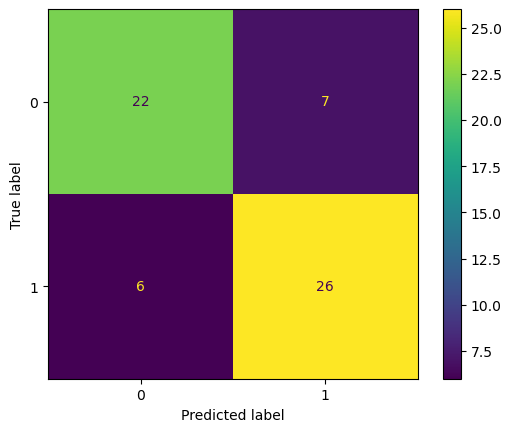

In [10]:
disp.plot()

- The upper-left quadrant displays the number of **true negatives**.
- The bottom-left quadrant displays the number of **false negatives**.
- The upper-right quadrant displays the number of **false positives**.
- The bottom-right quadrant displays the number of **true positives**.

## Five Fold Cross Validation

In [23]:
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Store results for each fold
dt_fold_results = []
dt_fold_times = []

In [25]:
fold_num = 1
for train_index, val_index in kf.split(x):
    # Split data
    x_train_fold, x_val_fold = x.iloc[train_index], x.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
    
    # ===== Decision Tree =====
    train_start = time.perf_counter()
    dt_model_fold = tree.DecisionTreeClassifier(random_state=42).fit(x_train_fold, y_train_fold)
    train_time_dt = time.perf_counter() - train_start
    
    predict_start = time.perf_counter()
    y_pred_dt = dt_model_fold.predict(x_val_fold)
    y_pred_proba_dt = dt_model_fold.predict_proba(x_val_fold)[:, 1]
    predict_time_dt = time.perf_counter() - predict_start
    
    total_time_dt = train_time_dt + predict_time_dt
    
    # Calculate metrics
    accuracy_dt = accuracy_score(y_val_fold, y_pred_dt)
    precision_dt = precision_score(y_val_fold, y_pred_dt, zero_division=0)
    recall_dt = recall_score(y_val_fold, y_pred_dt, zero_division=0)
    f1_dt = f1_score(y_val_fold, y_pred_dt, zero_division=0)
    roc_auc_dt = roc_auc_score(y_val_fold, y_pred_proba_dt)
    
    # Store results
    dt_fold_results.append({
        'fold': fold_num,
        'accuracy': accuracy_dt,
        'precision': precision_dt,
        'recall': recall_dt,
        'f1_score': f1_dt,
        'roc_auc': roc_auc_dt
    })
    
    dt_fold_times.append({
        'fold': fold_num,
        'train_time': train_time_dt,
        'predict_time': predict_time_dt,
        'total_time': total_time_dt
    })
    
    print(f"Fold {fold_num}:")
    print(f"  Decision Tree:")
    print(f"    Training time: {train_time_dt:.6f}s | Prediction time: {predict_time_dt:.6f}s | Total: {total_time_dt:.6f}s")
    print(f"    Accuracy: {accuracy_dt:.4f} | Precision: {precision_dt:.4f} | Recall: {recall_dt:.4f} | F1: {f1_dt:.4f} | AUC: {roc_auc_dt:.4f}")
    print()
    
    fold_num += 1

Fold 1:
  Decision Tree:
    Training time: 0.003408s | Prediction time: 0.002752s | Total: 0.006160s
    Accuracy: 0.7869 | Precision: 0.7879 | Recall: 0.8125 | F1: 0.8000 | AUC: 0.7856

Fold 2:
  Decision Tree:
    Training time: 0.003189s | Prediction time: 0.002297s | Total: 0.005485s
    Accuracy: 0.7541 | Precision: 0.6667 | Recall: 0.8462 | F1: 0.7458 | AUC: 0.7659

Fold 3:
  Decision Tree:
    Training time: 0.002521s | Prediction time: 0.002413s | Total: 0.004934s
    Accuracy: 0.8033 | Precision: 0.7188 | Recall: 0.8846 | F1: 0.7931 | AUC: 0.8137

Fold 4:
  Decision Tree:
    Training time: 0.017157s | Prediction time: 0.003514s | Total: 0.020671s
    Accuracy: 0.7000 | Precision: 0.7308 | Recall: 0.6333 | F1: 0.6786 | AUC: 0.7000

Fold 5:
  Decision Tree:
    Training time: 0.003896s | Prediction time: 0.003434s | Total: 0.007330s
    Accuracy: 0.7500 | Precision: 0.6786 | Recall: 0.7600 | F1: 0.7170 | AUC: 0.7514



In [27]:
# Convert results to DataFrames for analysis
dt_results_df = pd.DataFrame(dt_fold_results)
dt_times_df = pd.DataFrame(dt_fold_times)

In [29]:
# Print summary statistics over all folds
print("=" * 60)
print("Decision Tree - Metrics Summary (over all folds):")
print(f"  Accuracy:  {dt_results_df['accuracy'].mean():.4f} ± {dt_results_df['accuracy'].std():.4f}")
print(f"  Precision: {dt_results_df['precision'].mean():.4f} ± {dt_results_df['precision'].std():.4f}")
print(f"  Recall:    {dt_results_df['recall'].mean():.4f} ± {dt_results_df['recall'].std():.4f}")
print(f"  F1-Score:  {dt_results_df['f1_score'].mean():.4f} ± {dt_results_df['f1_score'].std():.4f}")
print(f"  ROC-AUC:   {dt_results_df['roc_auc'].mean():.4f} ± {dt_results_df['roc_auc'].std():.4f}")
print("=" * 60)

Decision Tree - Metrics Summary (over all folds):
  Accuracy:  0.7589 ± 0.0398
  Precision: 0.7165 ± 0.0480
  Recall:    0.7873 ± 0.0975
  F1-Score:  0.7469 ± 0.0513
  ROC-AUC:   0.7633 ± 0.0424


In [31]:
# Best fold (highest F1)
best_dt_f1 = dt_results_df.loc[dt_results_df['f1_score'].idxmax()]
best_dt_timing = dt_times_df[dt_times_df['fold'] == best_dt_f1['fold']].iloc[0]

print("Best Performing Fold (Highest F1-Score):")
print("-" * 60)
print(f"Fold {int(best_dt_f1['fold'])}:")
print(f"  Accuracy:  {best_dt_f1['accuracy']:.4f}")
print(f"  Precision: {best_dt_f1['precision']:.4f}")
print(f"  Recall:    {best_dt_f1['recall']:.4f}")
print(f"  F1-Score:  {best_dt_f1['f1_score']:.4f}")
print(f"  ROC-AUC:   {best_dt_f1['roc_auc']:.4f}")
print(f"  Training time:   {best_dt_timing['train_time']:.6f} seconds")
print(f"  Prediction time: {best_dt_timing['predict_time']:.6f} seconds")
print("-" * 60)

Best Performing Fold (Highest F1-Score):
------------------------------------------------------------
Fold 1:
  Accuracy:  0.7869
  Precision: 0.7879
  Recall:    0.8125
  F1-Score:  0.8000
  ROC-AUC:   0.7856
  Training time:   0.003408 seconds
  Prediction time: 0.002752 seconds
------------------------------------------------------------
